In [54]:
from IPython.display import Image, display

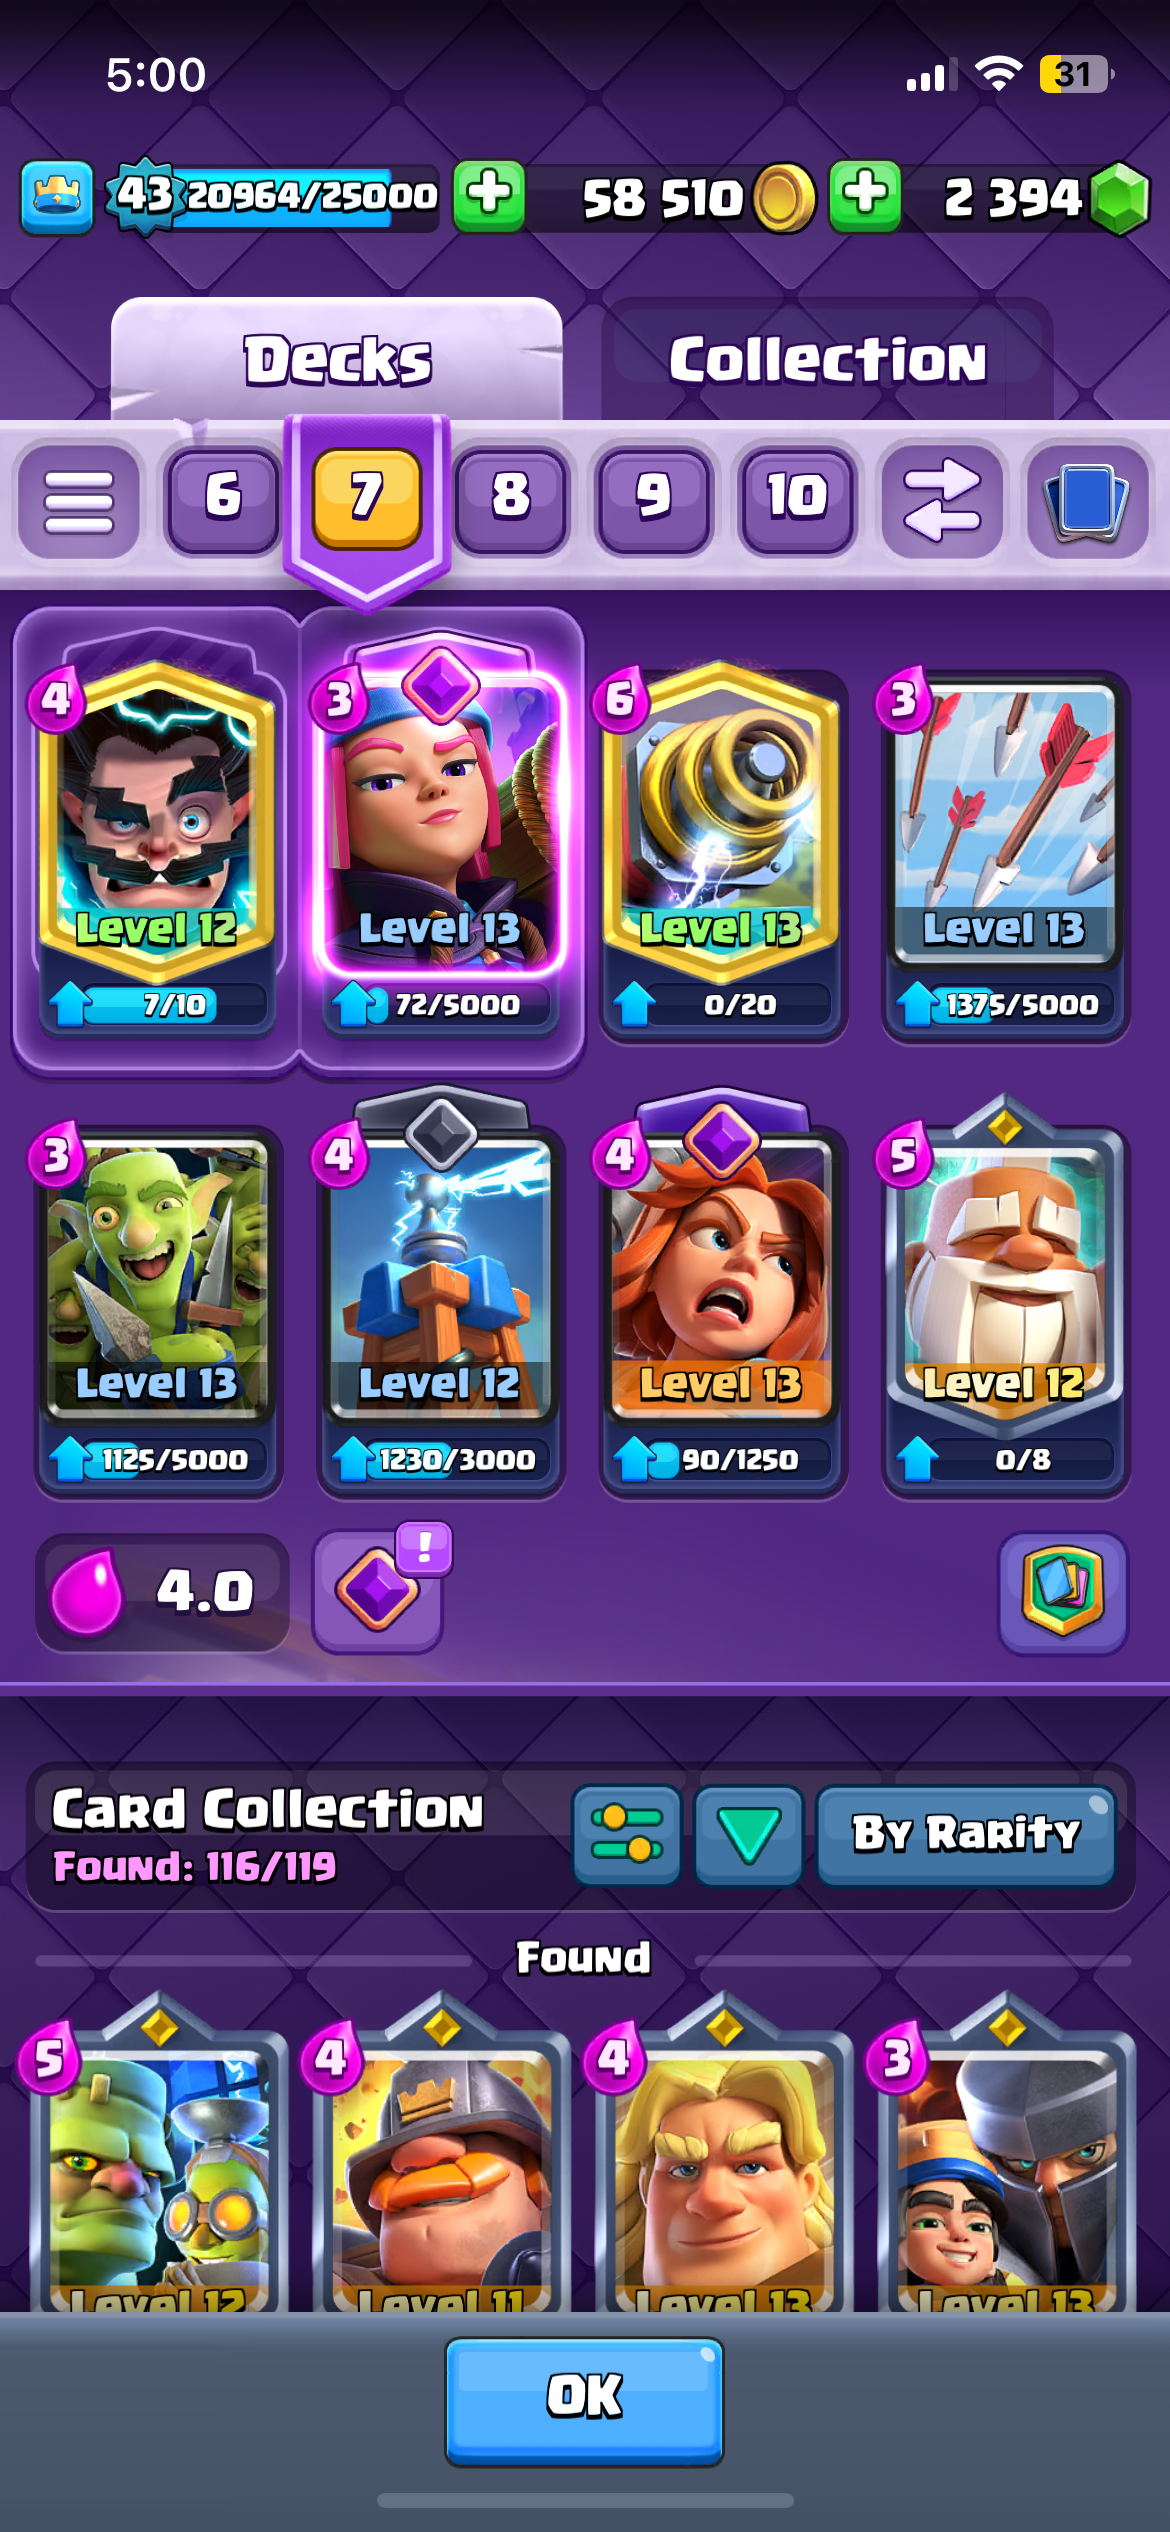

In [9]:
Image(filename="public/IMG_8557.png", width=300)

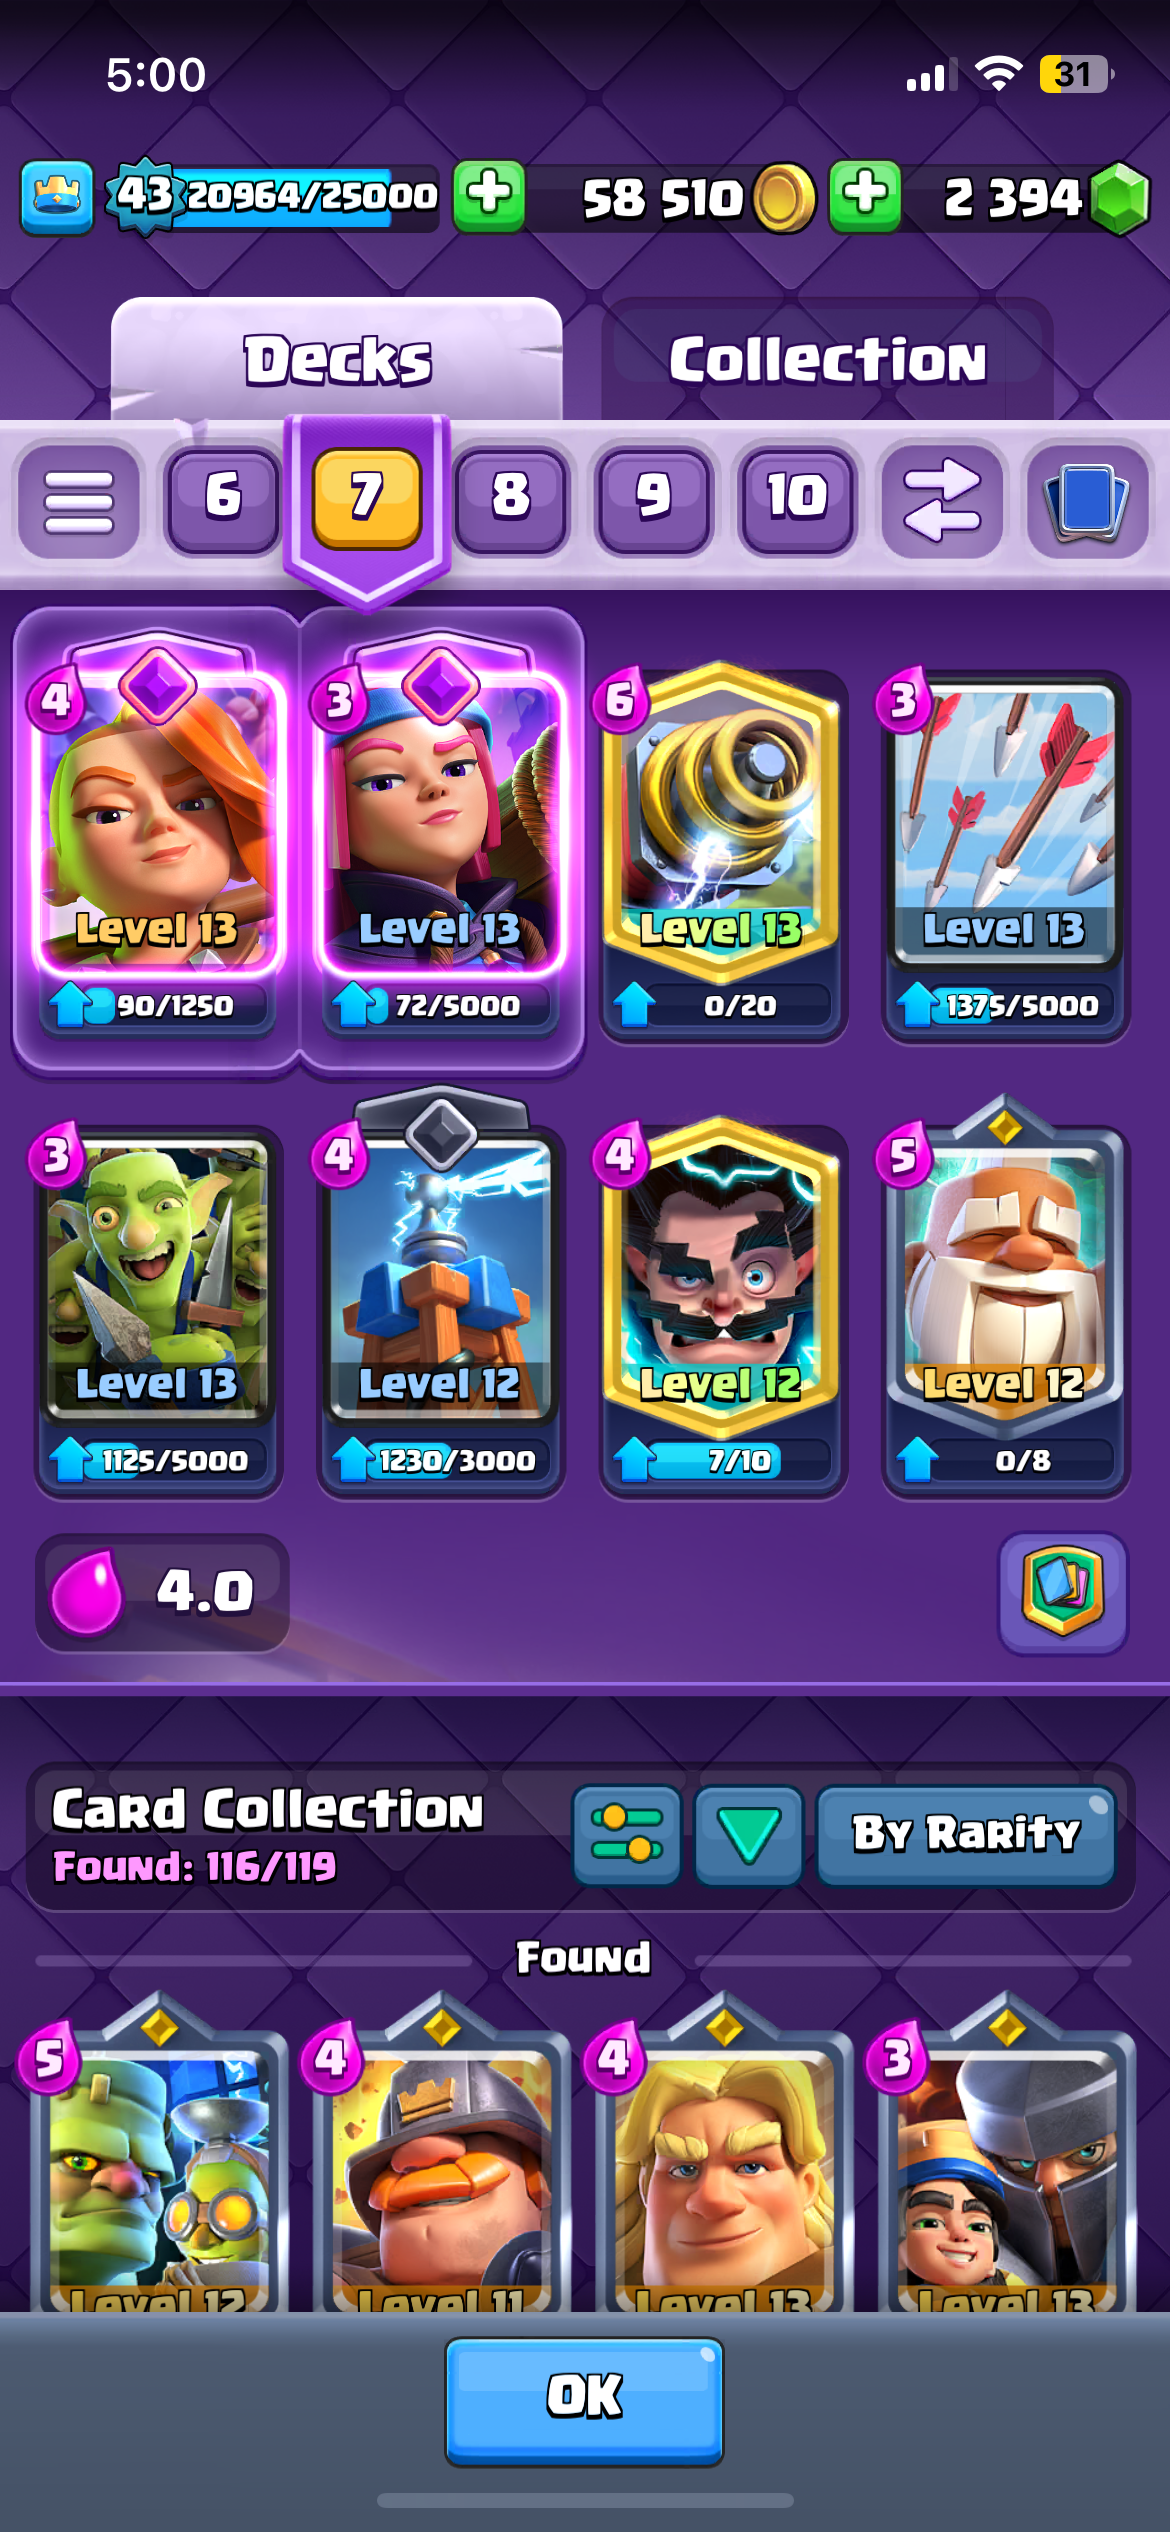

In [10]:
Image(filename="public/IMG_8556.png", width=300)

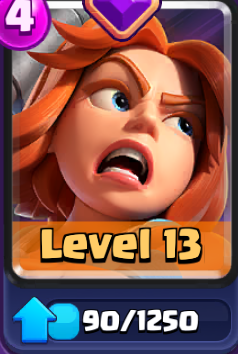

In [16]:
import cv2

# Load the image
img = cv2.imread("public/IMG_8557.png")

# Crop: img[y1:y2, x1:x2]
x = 600
y = 1139
width = 238
height = 354
cropped = img[y:y + height, x:x + width]  # Adjust coordinates as needed

# Save or display the cropped part
cv2.imwrite("public_write/cropped.png", cropped)

# Optional: Show inside notebook (convert to RGB)
from PIL import Image
from IPython.display import display

cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
display(Image.fromarray(cropped_rgb))


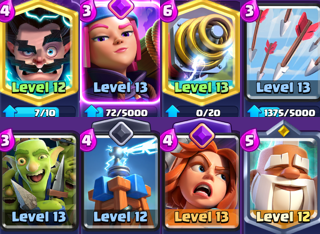

In [226]:
import cv2
from PIL import Image
from IPython.display import display

# Load the image
img = cv2.imread("public/IMG_8557.png")

# Crop parameters
start_x = 41
width = 238
height = 350
x_gap = 40

# List to hold resized cropped images
resized_cards = []

# Extract and resize each card
for y in [667, 1085]:
    x = start_x
    for i in range(4):
        cropped = img[y:y + height, x:x + width]
        cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(cropped_rgb)

        resized = pil_img.resize((80, int(80 * pil_img.height / pil_img.width)))  # Resize to fixed width
        resized_cards.append(resized)

        x += width + x_gap

# Split into two rows
row1 = resized_cards[:4]
row2 = resized_cards[4:]

# Compute dimensions
row_width = max(sum(img.width for img in row1), sum(img.width for img in row2))
row_height = max(img.height for img in row1)
total_height = row_height * 2

# Create final blank canvas
combined = Image.new("RGB", (row_width, total_height))

# Paste first row
x_offset = 0
for card in row1:
    combined.paste(card, (x_offset, 0))
    x_offset += card.width

# Paste second row
x_offset = 0
for card in row2:
    combined.paste(card, (x_offset, row_height))
    x_offset += card.width

# Display the final 2-row image
display(combined)


In [213]:
import cv2
import numpy as np

def are_images_similar(img1_pil, img2_pil, threshold=0.9):
    """
    Compare two PIL images for visual similarity using OpenCV template matching.
    
    Args:
        img1_pil (PIL.Image): First image.
        img2_pil (PIL.Image): Second image.
        threshold (float): Similarity threshold between 0 and 1.
    
    Returns:
        bool: True if images are similar, False otherwise.
    """
    # Convert PIL images to NumPy arrays (RGB → BGR)
    img1 = cv2.cvtColor(np.array(img1_pil), cv2.COLOR_RGB2BGR)
    img2 = cv2.cvtColor(np.array(img2_pil), cv2.COLOR_RGB2BGR)

    # Resize img2 to img1 size
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Convert both to grayscale
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Template match
    result = cv2.matchTemplate(gray1, gray2, cv2.TM_CCOEFF_NORMED)
    _, similarity, _, _ = cv2.minMaxLoc(result)

    return similarity >= threshold, similarity


In [131]:
are_images_similar(resized_cards[1], resized_cards[1])

(True, 1.0)

In [247]:
firecracker_label = Image.open("labels/Evolution/Firecracker.webp", width=100)
firecracker_label

TypeError: open() got an unexpected keyword argument 'width'

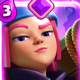

In [133]:
resized_cards[1]

In [136]:
are_images_similar(resized_cards[1], firecracker_label)

(False, 0.085720494389534)

In [137]:
# from skimage.metrics import structural_similarity as ssim
# import numpy as np
# import cv2

# def are_images_similar(img1_pil, img2_pil, threshold=0.6):
#     """
#     Compare two PIL images using SSIM and return True if they are visually similar.
    
#     Args:
#         img1_pil: First PIL.Image
#         img2_pil: Second PIL.Image
#         threshold: Float between 0–1. Higher = stricter.
    
#     Returns:
#         bool: True if similar, else False
#     """
#     # Convert to NumPy arrays
#     img1 = np.array(img1_pil.resize((100, 140)).convert('L'))  # Resize and grayscale
#     img2 = np.array(img2_pil.resize((100, 140)).convert('L'))  # Same size

#     score, _ = ssim(img1, img2, full=True)
#     return score >= threshold, score


In [138]:
are_images_similar(resized_cards[3], firecracker_label)

(False, 0.059865646064281464)

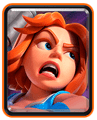

In [139]:
valk_label = Image.open("labels/Valk.webp")
valk_label

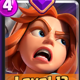

In [140]:
resized_cards[6]

In [141]:
are_images_similar(resized_cards[6], valk_label)

(False, 0.33671313524246216)

In [142]:
for i in range(8):
    print(are_images_similar(resized_cards[i], valk_label))

(False, -0.013628137297928333)
(False, 0.11279981583356857)
(False, -0.038457512855529785)
(False, 0.1778448522090912)
(False, 0.1885935515165329)
(False, 0.0629437267780304)
(False, 0.33671313524246216)
(False, 0.055986639112234116)


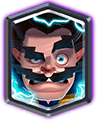

In [143]:
eWiz_label = Image.open("labels/eWiz.webp")
eWiz_label

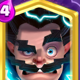

In [144]:
resized_cards[0]

In [145]:
for i in range(8):
    print(are_images_similar(resized_cards[i], eWiz_label))

(False, 0.006602737121284008)
(False, 0.02616964653134346)
(False, 0.15859395265579224)
(False, 0.13353924453258514)
(False, 0.034095801413059235)
(False, -0.019796429201960564)
(False, -0.07441771775484085)
(False, 0.13805682957172394)


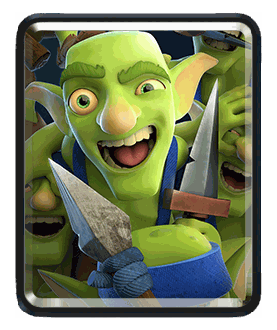

In [146]:
goblin_gang_label = Image.open("labels/goblin_gang.webp")
goblin_gang_label

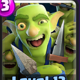

In [147]:
resized_cards[4]

In [148]:
for i in range(8):
    print(are_images_similar(resized_cards[i], eWiz_label))

(False, 0.006602737121284008)
(False, 0.02616964653134346)
(False, 0.15859395265579224)
(False, 0.13353924453258514)
(False, 0.034095801413059235)
(False, -0.019796429201960564)
(False, -0.07441771775484085)
(False, 0.13805682957172394)


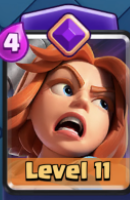

In [232]:
img = cv2.imread("labels/collection.png")
x = 305
y = 760
cropped = img[y:y + 200, x:x + 130]
cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
pil_img = Image.fromarray(cropped_rgb)

resized = pil_img

display(resized)

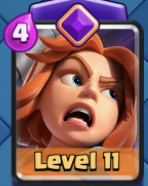

In [243]:
valk_label = Image.open("cards/valk_label_2.png")
valk_label

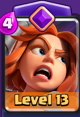

In [244]:
resized_cards[6]

In [245]:
print(are_images_similar(resized_cards[6], valk_label))

(False, 0.4704092741012573)


In [246]:
for i in range(8):
    print(are_images_similar(resized_cards[i], valk_label))

(False, -0.0720042809844017)
(False, 0.0969473347067833)
(False, -0.007135746534913778)
(False, -0.005240180529654026)
(False, 0.15227070450782776)
(False, 0.07638143748044968)
(False, 0.4704092741012573)
(False, 0.13223864138126373)
